In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from scipy.stats import zscore
from scipy.stats import pearsonr, spearmanr

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi
from matplotlib.colors import LinearSegmentedColormap

from matplotlib_venn import venn3_unweighted
from matplotlib_venn import venn2_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 2

# Load in data

In [2]:
%%time
# h5ad built in Hematokytos/anndatas/integrate_scfib_ihsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['log_norm'].copy()
adata

CPU times: user 954 ms, sys: 2.86 s, total: 3.82 s
Wall time: 7.52 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

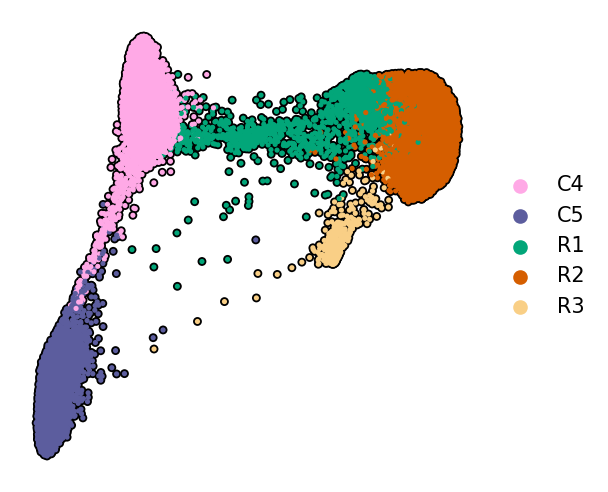

In [3]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    color=['cluster'],
    size=25,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    title='',
)

# FA graphs by batch

Library 2 (control)


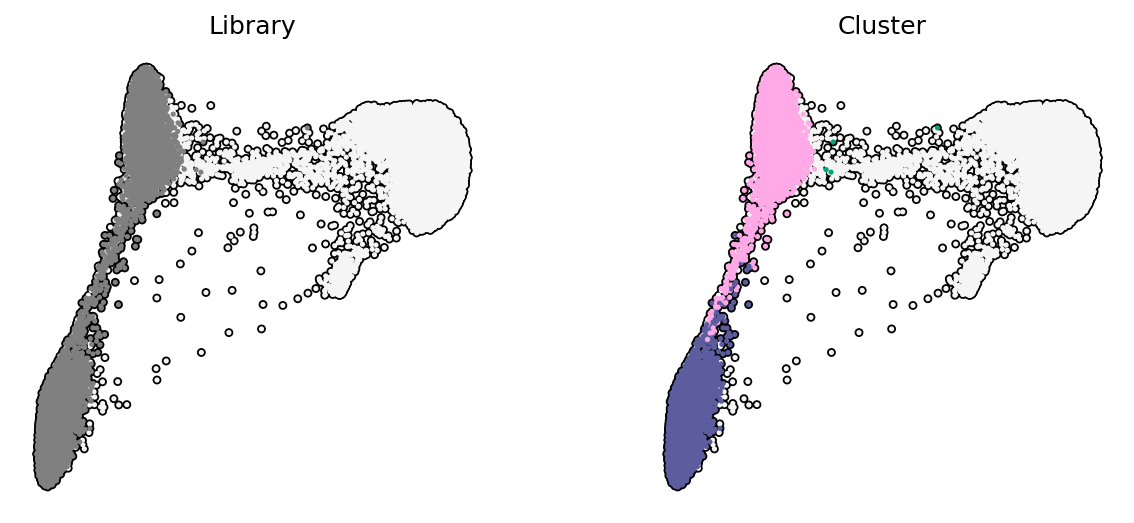

In [5]:
batches = adata.obs['batch'].cat.categories

batch_colors = {
    'fib': 'Grey',
    'hsc': 'deepskyblue',
}

adata.uns['batch_colors'] = [batch_colors[c] for c in batches]

mask = adata.obs['batch'] == 'fib'

print('Library 2 (control)')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    color=['batch', 'cluster'],
    mask_obs=mask,
    size=25,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    legend_loc='none',
    alpha=1,
    na_color='whitesmoke',
    title=['Library', 'Cluster'],
)

Library 1 (reprogram)


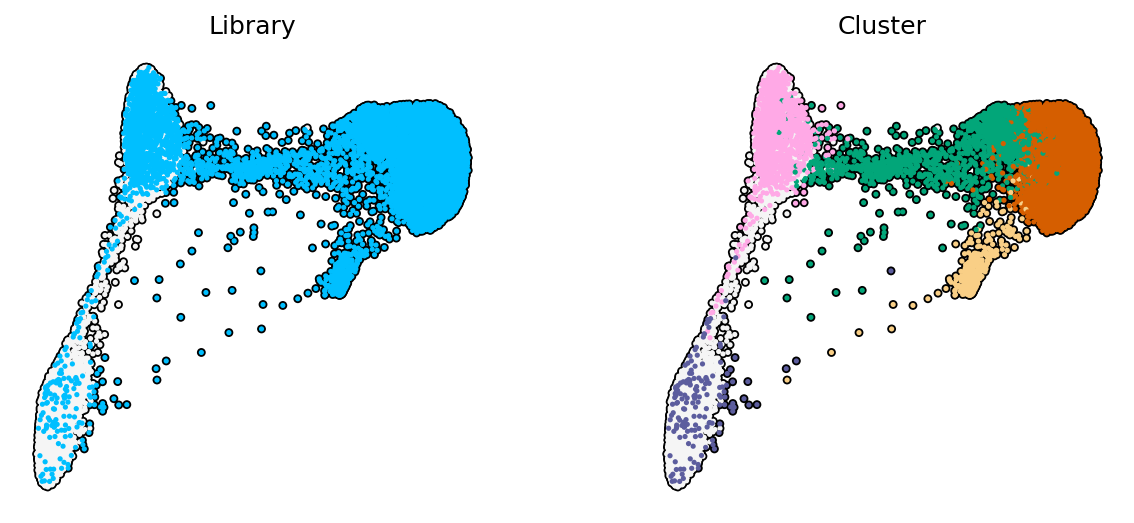

In [6]:
mask = adata.obs['batch'] == 'hsc'

print('Library 1 (reprogram)')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    color=['batch', 'cluster'],
    mask_obs=mask,
    size=25,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    legend_loc='none',
    alpha=1,
    na_color='whitesmoke',
    title=['Library', 'Cluster'],
)

# Spike-in counts

,cluster,batch,n cells
0,C4,fib,3262
1,C4,hsc,1350
2,C5,fib,3694
3,C5,hsc,158
4,R1,fib,4
5,R1,hsc,1982
6,R2,hsc,4343
7,R3,hsc,524


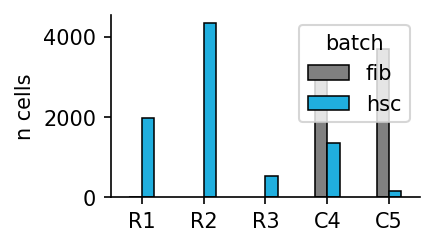

In [7]:
cluster_counts = adata.obs.groupby(['cluster', 'batch'], observed=True).size().reset_index(name='n cells')
display(cluster_counts)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 1.75

batch_colors = {
    'fib': 'Grey',
    'hsc': 'deepskyblue',
}

sns.barplot(
    data=cluster_counts,
    x='cluster',
    y='n cells',
    hue='batch',
    order=['R1', 'R2', 'R3', 'C4', 'C5'],
    hue_order=['fib', 'hsc'],
    palette=['Grey', 'deepskyblue'],
    # legend=False,
    width=0.4,
    ec='k',
    lw=0.75,
)

plt.xlabel('')

sns.despine()
plt.tight_layout()
plt.show()

# CD34 expression

In [8]:
low = '#131317' # dark
mid = '#3B80EB' # blue
high = '#F2D123' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

All cells


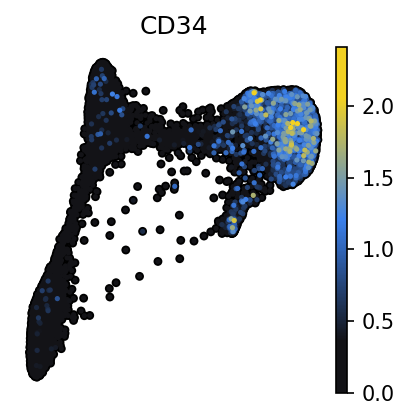

In [9]:
print('All cells')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata,
    color='CD34',
    na_color='whitesmoke',
    size=25,
    ncols=1,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    cmap=custom_cmap,
)

Library 1


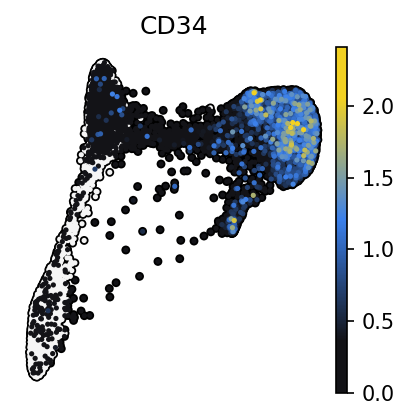

In [11]:
print('Library 1')

mask = adata.obs['batch'] == 'hsc'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata,
    color='CD34',
    mask_obs=mask,
    na_color='whitesmoke',
    size=25,
    ncols=1,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    cmap=custom_cmap,
)

Library 2


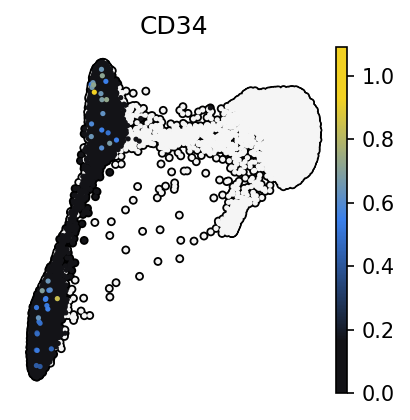

In [10]:
print('Library 2')

mask = adata.obs['batch'] == 'fib'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata,
    color='CD34',
    mask_obs=mask,
    na_color='whitesmoke',
    size=25,
    ncols=1,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    cmap=custom_cmap,
)

Spike-ins


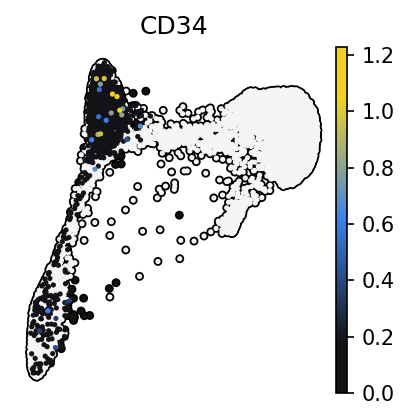

In [12]:
print('Spike-ins')

mask = (adata.obs['batch'] == 'hsc') & (adata.obs['cluster'].isin(['C4', 'C5']))

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata,
    color='CD34',
    mask_obs=mask,
    na_color='whitesmoke',
    size=25,
    ncols=1,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    cmap=custom_cmap,
)

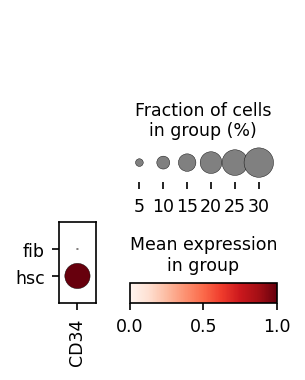

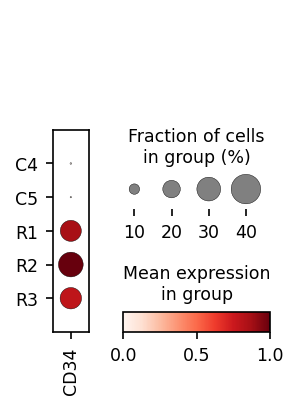

In [14]:
plt.rcParams['figure.dpi'] = 150
sc.pl.dotplot(
    adata,
    var_names=['CD34'],
    groupby='batch',
    standard_scale='var',
)
sc.pl.dotplot(
    adata,
    var_names=['CD34'],
    groupby='cluster',
    standard_scale='var',
)

# Spike-in GEX

In [15]:
# remove spike-in controls
adata.obs['spike'] = adata.obs['cluster'].copy()
adata.obs['spike'] = adata.obs['spike'].astype('str')

# identify hsc cells in control clusters
mask = (adata.obs['batch'] == 'hsc') & (adata.obs['cluster'].isin(['C4', 'C5']))

# label them as NaN
adata.obs.loc[mask, 'spike'] = 'spikes'

adata.obs['spike'] = adata.obs['spike'].astype('category')

print(adata.obs['spike'].value_counts(sort=False))
adata.obs.groupby('batch')['spike'].value_counts(sort=False)

spike
C4        3262
C5        3694
R1        1986
R2        4343
R3         524
spikes    1508
Name: count, dtype: int64


/tmp/ipykernel_3699409/3466022003.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('batch')['spike'].value_counts(sort=False)


batch  spike 
fib    C4        3262
       C5        3694
       R1           4
       R2           0
       R3           0
       spikes       0
hsc    C4           0
       C5           0
       R1        1982
       R2        4343
       R3         524
       spikes    1508
Name: count, dtype: int64

In [16]:
print(adata.obs['cluster'].value_counts())

cluster
C4    4612
R2    4343
C5    3852
R1    1986
R3     524
Name: count, dtype: int64


In [17]:
# Load in fib marker genes
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "../resources/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

subset = pang[['Fibroblasts', 'Hematopoietic Stem Cells']]

panglao_markers = subset[subset.any(axis=1)]

print(f"Total unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(len(fib_genes))

Total unique genes across selected types: 398
215


In [18]:
# get top expressed fib genes in controls
adata_fib = adata[adata.obs['batch'] == 'fib'].copy()

adata_fib.X = adata_fib.layers['log_norm'].copy()

X = adata_fib[:, fib_genes].X

# Handle sparse matrices
if not isinstance(X, np.ndarray):
    X = X.toarray()
    
# Compute mean expression per gene
mean_expr = X.mean(axis=0)

# Create a ranked Series
mean_expr = pd.Series(mean_expr, index=fib_genes)

n_genes = 15

# Top 15 expressed fib genes
top_fib_genes = mean_expr.sort_values(ascending=False).head(n_genes).index.tolist()

top_fib_genes

['VIM',
 'COL1A2',
 'COL1A1',
 'S100A4',
 'DCN',
 'TAGLN',
 'SPARC',
 'FN1',
 'COL6A2',
 'IGFBP6',
 'COL6A1',
 'MYL9',
 'GREM1',
 'COL3A1',
 'FSTL1']

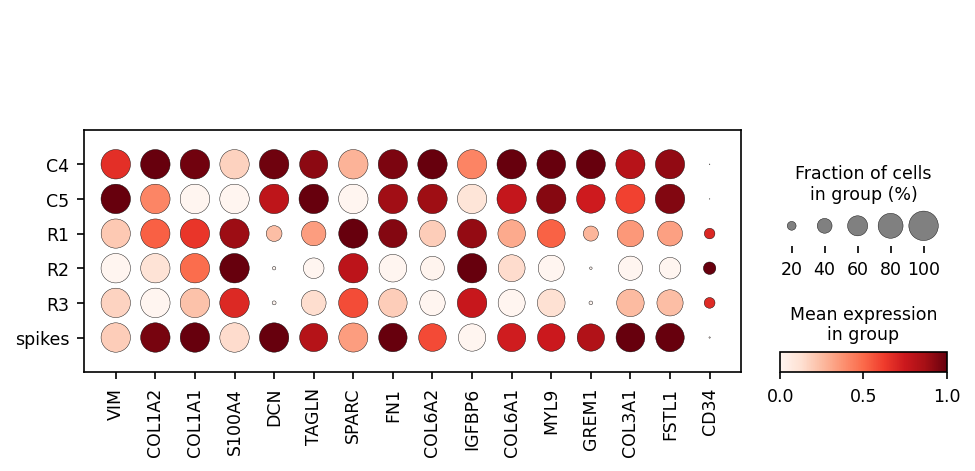

In [20]:
top_fib_genes1 = top_fib_genes + ['CD34']

plt.rcParams['figure.dpi'] = 150
sc.pl.dotplot(
    adata,
    var_names=top_fib_genes1,
    groupby='spike',
    layer='log_norm',
    standard_scale='var',
)

# DEG compare

In [21]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            # make sure either group of interest OR reference has % cells expressing above threshold
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of group OR reference cells.")
        
        else:
            # Only apply pct_nz_group filter to upregulated genes
            upregulated_mask = tmp['logfoldchanges'] > 0
            keep_mask = (~upregulated_mask) | (tmp['pct_nz_group'] > pct_nz_thresh)
            tmp = tmp[keep_mask]

            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed upregaulted genes expressed in less than {pct_nz_thresh*100}% of cells. Kept all downregulated genes.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

## cluster level

In [22]:
# remove spike-in controls
adata.obs['cluster_clean'] = adata.obs['cluster'].copy()

# identify hsc cells in control clusters
mask = (adata.obs['batch'] == 'hsc') & (adata.obs['cluster'].isin(['C4', 'C5']))
# label them as NaN
adata.obs.loc[mask, 'cluster_clean'] = np.nan

adata.obs['cluster_clean'] = adata.obs['cluster_clean'].astype('category')

print(adata.obs['cluster_clean'].value_counts(sort=False))

cluster_clean
C4    3262
C5    3694
R1    1986
R2    4343
R3     524
Name: count, dtype: int64


In [23]:
# degs without spike-ins
sc.tl.rank_genes_groups(
    adata, 
    groupby='cluster_clean',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='cluster_deg',
)

# degs with spike-ins
sc.tl.rank_genes_groups(
    adata, 
    groupby='cluster',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='cluster_deg_wspike',
)

ranking genes
    finished (0:00:42)
ranking genes
    finished (0:00:41)


In [24]:
# without spike-ins
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_deg',
    pval_cutoff=0.05,
)

print(f"N unique DEGs: {deg['names'].nunique()}")

# gene info
gtf = adata.var[['gene_type']].copy()
gtf = gtf.reset_index(names='names')
print(gtf.shape)

deg = pd.merge(deg, gtf, how='left', on='names')
print(f"After merging w GTF: {deg['names'].nunique()}")

# remove ENSG and MT- and ribo genes
deg = deg[~deg['names'].str.startswith(('ENSG', 'MT-', 'RP'))]

# filter for protein-coding
deg = deg[deg['gene_type'] == 'protein_coding']

print(f"Protein-coding n genes: {deg['names'].nunique()}")
deg.head()

N unique DEGs: 12367
(23434, 2)
After merging w GTF: 12367
Protein-coding n genes: 10596


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,gene_type
0,C4,TSPAN9,76.823090,1.737851,0.0,0.0,1.000000,0.986147,protein_coding
5,C4,IFITM1,68.229347,2.646459,0.0,0.0,1.000000,0.889755,protein_coding
6,C4,IFITM3,68.225212,1.493457,0.0,0.0,1.000000,0.996682,protein_coding
7,C4,IFIT2,67.914444,3.575133,0.0,0.0,0.918455,0.277478,protein_coding
8,C4,IFI16,66.300896,2.644392,0.0,0.0,0.998467,0.527665,protein_coding


In [25]:
# with spike-ins
deg1 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_deg_wspike',
    pval_cutoff=0.05,
)

print(f"N unique DEGs: {deg1['names'].nunique()}")

deg1 = pd.merge(deg1, gtf, how='left', on='names')
print(f"After merging w GTF: {deg1['names'].nunique()}")

# remove ENSG and MT- and ribo genes
deg1 = deg1[~deg1['names'].str.startswith(('ENSG', 'MT-', 'RP'))]

# filter for protein-coding
deg1 = deg1[deg1['gene_type'] == 'protein_coding']

print(f"Protein-coding n genes: {deg1['names'].nunique()}")
deg1.head()

N unique DEGs: 12380
After merging w GTF: 12380
Protein-coding n genes: 10635


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,gene_type
0,C4,DCN,81.276306,3.448478,0.0,0.0,0.999566,0.465764,protein_coding
1,C4,LUM,76.422882,2.977524,0.0,0.0,0.986774,0.438674,protein_coding
2,C4,TNFRSF11B,75.528488,3.440215,0.0,0.0,0.954683,0.375806,protein_coding
3,C4,THBS1,74.920853,3.203752,0.0,0.0,0.990026,0.480149,protein_coding
4,C4,CALD1,74.428589,1.909249,0.0,0.0,0.999133,0.958898,protein_coding


## library level

In [26]:
mapping = {
    'R1': 'reprogramming',
    'R2': 'reprogramming',
    'R3': 'reprogramming',
    'C4': 'control',
    'C5': 'control',
}

adata.obs['group_clean'] = adata.obs['cluster_clean'].map(mapping)
adata.obs['group'] = adata.obs['cluster'].map(mapping) # with spike-in controls

sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    reference='control',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='broad_deg',
)

sc.tl.rank_genes_groups(
    adata, 
    groupby='group_clean',
    reference='control',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='broad_deg_clean',
)

ranking genes


... storing 'group_clean' as categorical
... storing 'group' as categorical


    finished (0:00:55)
ranking genes
    finished (0:00:48)


In [27]:
print(adata.obs['group'].value_counts())
print(adata.obs['group_clean'].value_counts())

group
control          8464
reprogramming    6853
Name: count, dtype: int64
group_clean
control          6956
reprogramming    6853
Name: count, dtype: int64


In [28]:
# without spike-ins
deg_no = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='broad_deg_clean',
    pval_cutoff=0.05,
)

print(deg_no.shape)
deg_no.head()

deg_no = get_significant_DEGs(deg_no, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(f"N unique DEGs: {deg_no['names'].nunique()}")
print(deg_no.shape)
deg_no.head()

(11609, 6)
Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
N unique significant DEGs: 2700

N unique DEGs: 2700
(2700, 7)


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,MGP,98.763618,8.232561,0.0,0.0,0.978841,8.232561
1,KRT18,96.562759,5.562368,0.0,0.0,0.972129,5.562368
2,CLU,95.765785,4.721476,0.0,0.0,0.976069,4.721476
3,S100A6,95.404236,1.502948,0.0,0.0,1.000000,1.502948
4,S100A10,91.618324,2.272671,0.0,0.0,0.994893,2.272671


In [29]:
# with spike-ins
deg_with = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='broad_deg',
    pval_cutoff=0.05,
)

print(deg_with.shape)
deg_with.head()


deg_with = get_significant_DEGs(deg_with, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.3)
print(f"N unique DEGs: {deg_with['names'].nunique()}")
print(deg_with.shape)
deg_with.head()

(11332, 6)
Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed upregaulted genes expressed in less than 30.0% of cells. Kept all downregulated genes.
N unique significant DEGs: 2438

N unique DEGs: 2438
(2438, 7)


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,MGP,103.028625,7.695378,0.0,0.0,0.978841,7.695378
1,KRT18,101.187988,5.599798,0.0,0.0,0.972129,5.599798
2,CLU,100.182175,4.708968,0.0,0.0,0.976069,4.708968
3,S100A6,99.576378,1.506964,0.0,0.0,1.000000,1.506964
4,S100A10,96.766731,2.471691,0.0,0.0,0.994893,2.471691


In [30]:
print(deg_with['logfoldchanges'].max())
print(deg_no['logfoldchanges'].max())

8.887263
32.168385


In [31]:
### with spike-ins
df1 = (
    deg_with[['names', 'logfoldchanges', 'pvals_adj']]
    .rename(columns={
        'logfoldchanges': 'logFC_with',
        'pvals_adj': 'padj_with'
    })
)   
               
### without spike-ins
df2 = (
    deg_no[['names', 'logfoldchanges', 'pvals_adj']]
    .rename(columns={
        'logfoldchanges': 'logFC_no',
        'pvals_adj': 'padj_no'
    })
)

# Inner join on gene names
dfm = df1.merge(df2, on='names', how='inner')

print(f"Number of shared DEGs: {dfm.shape[0]}")

Number of shared DEGs: 2399


In [32]:
# Compute correlations
pearson_r, pearson_p = pearsonr(dfm['logFC_with'], dfm['logFC_no'])
spearman_r, spearman_p = spearmanr(dfm['logFC_with'], dfm['logFC_no'])

print(f'{pearson_r:.10f}')
print(f'{spearman_r:.10f}')

0.8554742932
0.9830898604


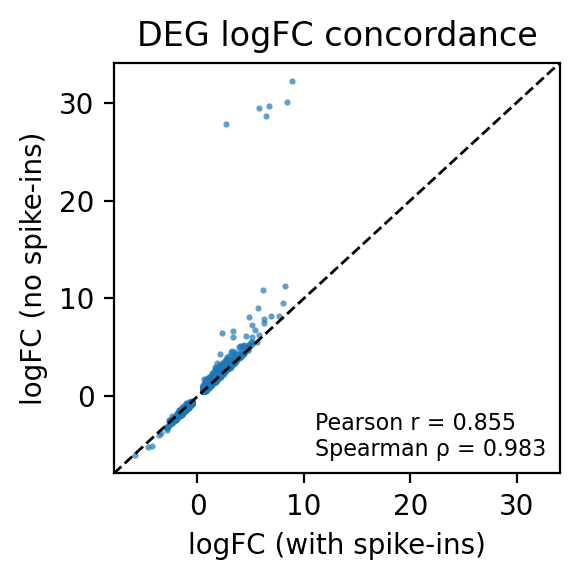

In [34]:
plt.figure(figsize=(3, 3), dpi=200)

sns.scatterplot(
    data=dfm,
    x='logFC_with',
    y='logFC_no',
    s=5,
    linewidth=0,
    alpha=0.7
)

# Identity line
lims = [
    np.min([plt.xlim()[0], plt.ylim()[0]]),
    np.max([plt.xlim()[1], plt.ylim()[1]])
]
plt.plot(lims, lims, '--', color='black', linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('logFC (with spike-ins)')
plt.ylabel('logFC (no spike-ins)')

plt.title('DEG logFC concordance')

# Correlation annotation
plt.text(
    0.45, 0.15,
    f'Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_r:.3f}',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=8
)

plt.tight_layout()
plt.show()

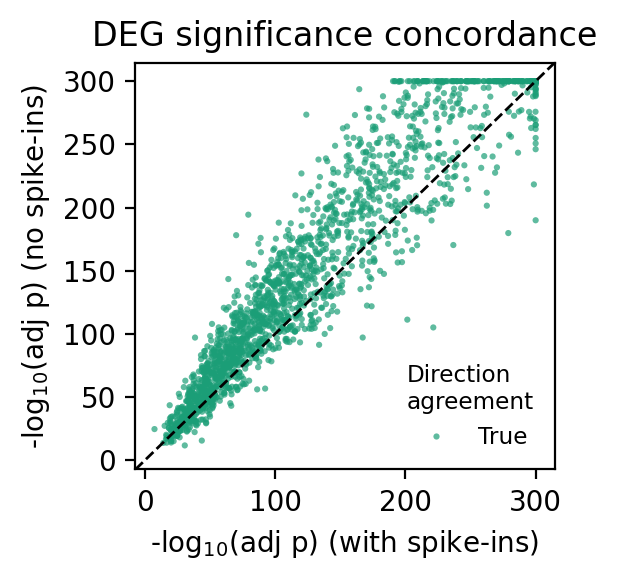

In [35]:
# Avoid -inf
eps = 1e-300
dfm['neglog10_p_with'] = -np.log10(dfm['padj_with'] + eps)
dfm['neglog10_p_no']   = -np.log10(dfm['padj_no'] + eps)

dfm['direction_agreement'] = np.sign(dfm['logFC_with']) == np.sign(dfm['logFC_no'])


plt.figure(figsize=(3, 3), dpi=200)

sns.scatterplot(
    data=dfm,
    x='neglog10_p_with',
    y='neglog10_p_no',
    hue='direction_agreement',
    palette={True: '#1b9e77', False: '#d95f02'},
    s=5,
    linewidth=0,
    alpha=0.7
)

# Identity line
lims = [
    np.min([plt.xlim()[0], plt.ylim()[0]]),
    np.max([plt.xlim()[1], plt.ylim()[1]])
]
plt.plot(lims, lims, '--', color='black', linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('-log$_{10}$(adj p) (with spike-ins)')
plt.ylabel('-log$_{10}$(adj p) (no spike-ins)')

plt.title('DEG significance concordance')

plt.legend(
    title='Direction\nagreement',
    loc='lower right',
    frameon=False,
    fontsize='small',
    title_fontsize='small',
    
)

plt.tight_layout()
plt.show()

In [36]:
## Union
genes_with = set(deg_with['names'])
genes_no   = set(deg_no['names'])

intersection = genes_with & genes_no
only_with    = genes_with - genes_no
only_no      = genes_no   - genes_with
union        = genes_with | genes_no

print(f"Total: {len(intersection) + len(only_with) + len(only_no)}")
print(f"With spike-ins only: {len(only_with)}")
print(f"No spike-ins only:   {len(only_no)}")
print(f"Intersection:        {len(intersection)}")

Total: 2739
With spike-ins only: 39
No spike-ins only:   301
Intersection:        2399


In [37]:
print(", ".join(sorted(list(only_with))))

ARMC9, BBLN, BMERB1, CAST, CCND1, CD59, CIR1, COX20, DSE, EHD4, EXT1, FARP1, FAT1, FBN1, GATA2, IL6ST, LEPROT, MEG3, MT1E, MT1X, MTCH2, MTHFS, NR3C1, OSBPL3, OXTR, PAPSS1, PARD3B, PKM, PRKACB, PRKG1, RBPMS, RUNX1, SASH1, SOCS5, TXNIP, UGDH, VAMP5, VCP, ZEB2


In [38]:
jaccard = len(intersection) / len(union)
print(f"Jaccard index: {jaccard:.3f}")

Jaccard index: 0.876


Overlap of DEGs (relative to control) with and without spike-ins


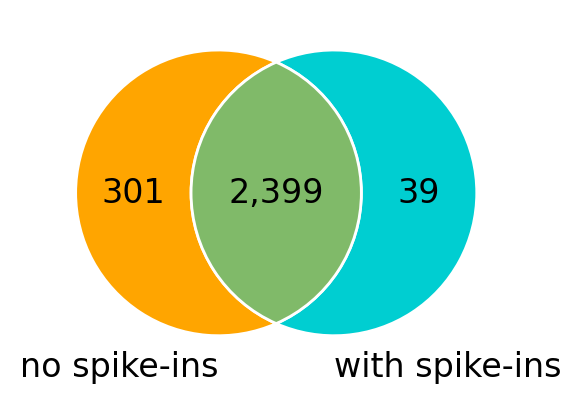

In [39]:
print('Overlap of DEGs (relative to control) with and without spike-ins')

venn_ids = {
    '10': ['no spike-ins'],
    '01': ['with spike-ins'],
    '11': ['no spike-ins', 'with spike-ins'],
}

colors_rgb = {
    'no spike-ins': mcolors.to_rgb('orange'),
    'with spike-ins': mcolors.to_rgb('darkturquoise'),
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

group_names = ['no spike-ins', 'with spike-ins']

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 200
plt.figure(figsize=(3, 3))

venn = venn2_unweighted(
    [genes_no, genes_with],
    set_labels=group_names
)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(12)
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')


plt.tight_layout()
plt.show()

In [40]:
## Union
# upregulated
genes_with = set(deg_with[deg_with['logfoldchanges'] > 0]['names'])
genes_no   = set(deg_no[deg_no['logfoldchanges'] > 0]['names'])

intersection = genes_with & genes_no
only_with    = genes_with - genes_no
only_no      = genes_no   - genes_with
union        = genes_with | genes_no

print(f"Total: {len(intersection) + len(only_with) + len(only_no)}")
print(f"With spike-ins only: {len(only_with)}")
print(f"No spike-ins only:   {len(only_no)}")
print(f"Intersection:        {len(intersection)}")

jaccard = len(intersection) / len(union)
print(f"Jaccard index: {jaccard:.3f}")

Total: 1789
With spike-ins only: 16
No spike-ins only:   162
Intersection:        1611
Jaccard index: 0.901


In [41]:
print(", ".join(sorted(list(only_with))))

BBLN, CAST, CCND1, CD59, COX20, EHD4, GATA2, MT1E, MT1X, MTCH2, MTHFS, OXTR, PAPSS1, PKM, VAMP5, VCP


Overlap of upregulated DEGs (relative to control) with and without spike-ins


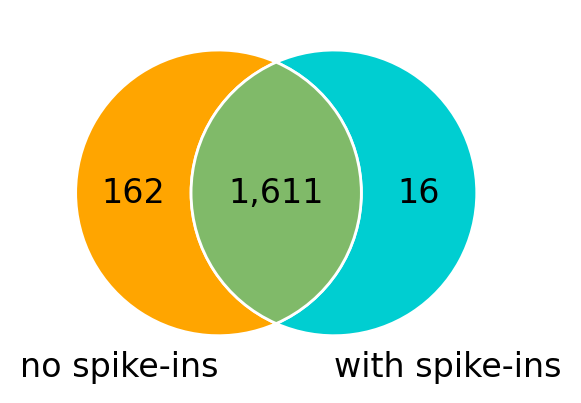

In [42]:
print('Overlap of upregulated DEGs (relative to control) with and without spike-ins')

venn_ids = {
    '10': ['no spike-ins'],
    '01': ['with spike-ins'],
    '11': ['no spike-ins', 'with spike-ins'],
}

colors_rgb = {
    'no spike-ins': mcolors.to_rgb('orange'),
    'with spike-ins': mcolors.to_rgb('darkturquoise'),
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

group_names = ['no spike-ins', 'with spike-ins']

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 200
plt.figure(figsize=(3, 3))

venn = venn2_unweighted(
    [genes_no, genes_with],
    set_labels=group_names
)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(12)
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')


plt.tight_layout()
plt.show()

In [43]:
# downregulated
genes_with = set(deg_with[deg_with['logfoldchanges'] < 0]['names'])
genes_no   = set(deg_no[deg_no['logfoldchanges'] < 0]['names'])

intersection = genes_with & genes_no
only_with    = genes_with - genes_no
only_no      = genes_no   - genes_with
union        = genes_with | genes_no

print(f"Total: {len(intersection) + len(only_with) + len(only_no)}")
print(f"With spike-ins only: {len(only_with)}")
print(f"No spike-ins only:   {len(only_no)}")
print(f"Intersection:        {len(intersection)}")

jaccard = len(intersection) / len(union)
print(f"Jaccard index: {jaccard:.3f}")

Total: 950
With spike-ins only: 23
No spike-ins only:   139
Intersection:        788
Jaccard index: 0.829


In [44]:
print(", ".join(sorted(list(only_with))))

ARMC9, BMERB1, CIR1, DSE, EXT1, FARP1, FAT1, FBN1, IL6ST, LEPROT, MEG3, NR3C1, OSBPL3, PARD3B, PRKACB, PRKG1, RBPMS, RUNX1, SASH1, SOCS5, TXNIP, UGDH, ZEB2


Overlap of downregulated DEGs (relative to control) with and without spike-ins


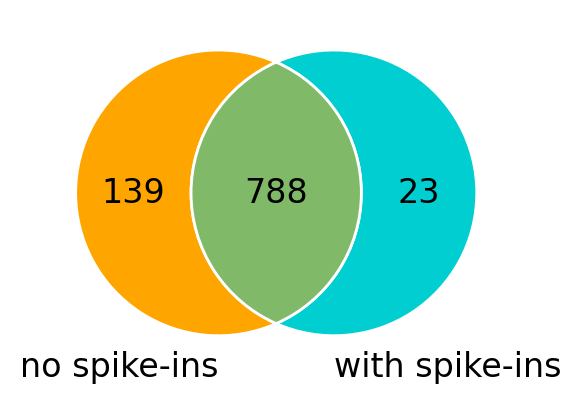

In [45]:
print('Overlap of downregulated DEGs (relative to control) with and without spike-ins')

venn_ids = {
    '10': ['no spike-ins'],
    '01': ['with spike-ins'],
    '11': ['no spike-ins', 'with spike-ins'],
}

colors_rgb = {
    'no spike-ins': mcolors.to_rgb('orange'),
    'with spike-ins': mcolors.to_rgb('darkturquoise'),
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

group_names = ['no spike-ins', 'with spike-ins']

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 200
plt.figure(figsize=(3, 3))

venn = venn2_unweighted(
    [genes_no, genes_with],
    set_labels=group_names
)

for subset_id, sets in venn_ids.items():
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        color = blend([colors_rgb[s] for s in sets])
        patch.set_facecolor(color)
        patch.set_edgecolor('white')
        patch.set_linewidth(1)
        patch.set_alpha(1)
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text(f"{int(label.get_text()):,}")
        label.set_fontsize(12)
        label.set_horizontalalignment('center')
        label.set_verticalalignment('center')


plt.tight_layout()
plt.show()